Speech FFT shape: (100, 257)
Non-speech FFT shape: (100, 257)


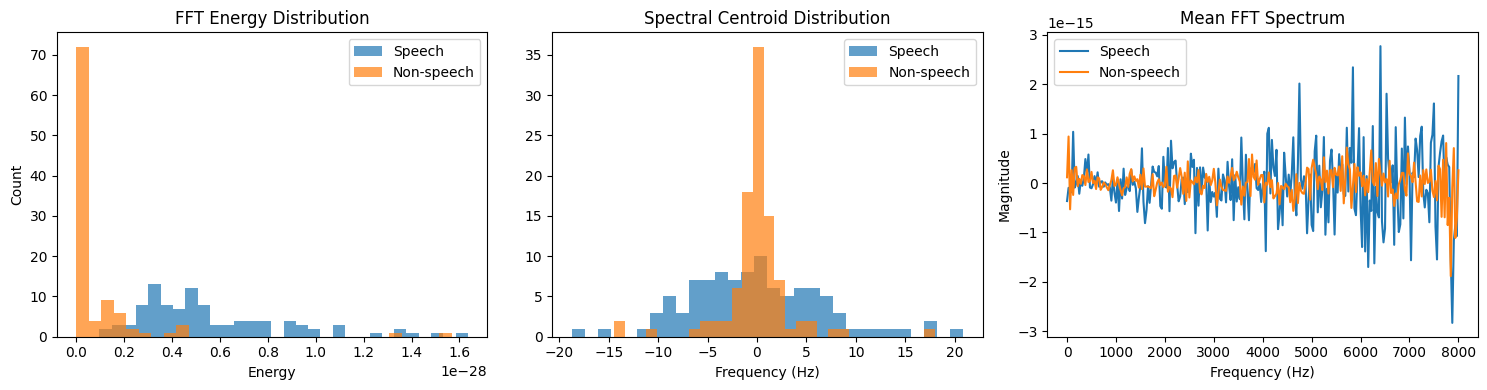

===== SUMMARY =====
Mean Energy - Speech     : 5.677240230463572e-29
Mean Energy - Non-speech : 9.143469379933748e-30
Mean Centroid - Speech     : -0.05122944714643188
Mean Centroid - Non-speech : -0.043220720740011744


In [ ]:
# FFT speech vs non-speech

import os
import numpy as np
import matplotlib.pyplot as plt

# =======================
# CONFIG
# =======================
speech_dir = r"D:\FPT_prj\preprocess_data\speech\fft"
nonspeech_dir = r"D:\FPT_prj\preprocess_data\non-speech\fft"

SAMPLE_RATE = 16000   # đổi nếu khác
N_FFT = 512           # đổi nếu khác

# =======================
# LOAD FFT FILES
# =======================
def load_fft_folder(folder):
    specs = []
    for file in os.listdir(folder):
        if file.endswith(".npy"):
            data = np.load(os.path.join(folder, file))
            if data.ndim == 2:
                data = data.mean(axis=0)  # mean over frames
            specs.append(data)
    return np.array(specs)

speech_fft = load_fft_folder(speech_dir)
nonspeech_fft = load_fft_folder(nonspeech_dir)

print("Speech FFT shape:", speech_fft.shape)
print("Non-speech FFT shape:", nonspeech_fft.shape)

# =======================
# FEATURE 1: ENERGY
# =======================
speech_energy = np.mean(speech_fft ** 2, axis=1)
nonspeech_energy = np.mean(nonspeech_fft ** 2, axis=1)

# =======================
# FEATURE 2: SPECTRAL CENTROID
# =======================
freqs = np.linspace(0, SAMPLE_RATE / 2, speech_fft.shape[1])

def spectral_centroid(mag):
    return np.sum(freqs * mag) / (np.sum(mag) + 1e-10)

speech_centroid = np.array([spectral_centroid(x) for x in speech_fft])
nonspeech_centroid = np.array([spectral_centroid(x) for x in nonspeech_fft])

# =======================
# VISUALIZATION
# =======================
plt.figure(figsize=(15, 4))

# --- ENERGY ---
plt.subplot(1, 3, 1)
plt.hist(speech_energy, bins=30, alpha=0.7, label="Speech")
plt.hist(nonspeech_energy, bins=30, alpha=0.7, label="Non-speech")
plt.title("FFT Energy Distribution")
plt.xlabel("Energy")
plt.ylabel("Count")
plt.legend()

# --- SPECTRAL CENTROID ---
plt.subplot(1, 3, 2)
plt.hist(speech_centroid, bins=30, alpha=0.7, label="Speech")
plt.hist(nonspeech_centroid, bins=30, alpha=0.7, label="Non-speech")
plt.title("Spectral Centroid Distribution")
plt.xlabel("Frequency (Hz)")
plt.legend()

# --- MEAN SPECTRUM ---
plt.subplot(1, 3, 3)
plt.plot(freqs, speech_fft.mean(axis=0), label="Speech")
plt.plot(freqs, nonspeech_fft.mean(axis=0), label="Non-speech")
plt.title("Mean FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()

plt.tight_layout()
plt.show()

# =======================
# NUMERICAL COMPARISON
# =======================
print("===== SUMMARY =====")
print("Mean Energy - Speech     :", speech_energy.mean())
print("Mean Energy - Non-speech :", nonspeech_energy.mean())
print("Mean Centroid - Speech     :", speech_centroid.mean())
print("Mean Centroid - Non-speech :", nonspeech_centroid.mean())


Speech STFT shape     : (100, 257)
Non-speech STFT shape : (100, 257)


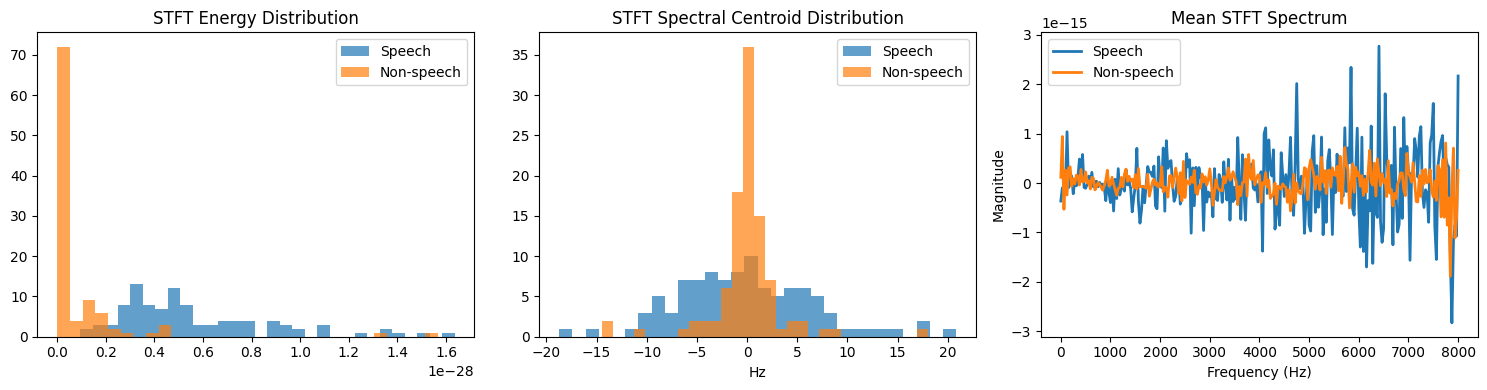


===== SUMMARY =====
Mean Energy - Speech     : 5.677240230463572e-29
Mean Energy - Non-speech : 9.143469379933748e-30
Mean Centroid - Speech     : -0.05122944714643188
Mean Centroid - Non-speech : -0.043220720740011744


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt

# =======================
# CONFIG
# =======================
speech_dir = r"D:\FPT_prj\preprocess_data\speech\stft"
nonspeech_dir = r"D:\FPT_prj\preprocess_data\non-speech\stft"

SAMPLE_RATE = 16000
TARGET_BINS = 257   # chuẩn cho N_FFT = 512 → 512//2 + 1

# =======================
# LOAD + NORMALIZE STFT
# =======================
def load_stft_folder(folder, target_bins):
    specs = []

    for file in os.listdir(folder):
        if not file.endswith(".npy"):
            continue

        stft = np.load(os.path.join(folder, file))

        # phải là (time, freq)
        if stft.ndim != 2:
            print(f"Skip {file}: not 2D")
            continue

        if stft.shape[1] != target_bins:
            print(f"Skip {file}: freq bins != {target_bins}")
            continue

        # mean over time (axis=0)
        mean_spec = np.mean(stft, axis=0)

        specs.append(mean_spec)

    if len(specs) == 0:
        raise ValueError(f"No valid STFT files in {folder}")

    return np.stack(specs, axis=0)

speech_stft = load_stft_folder(speech_dir, TARGET_BINS)
nonspeech_stft = load_stft_folder(nonspeech_dir, TARGET_BINS)

print("Speech STFT shape     :", speech_stft.shape)
print("Non-speech STFT shape :", nonspeech_stft.shape)

# =======================
# FEATURE 1: ENERGY
# =======================
speech_energy = np.mean(speech_stft ** 2, axis=1)
nonspeech_energy = np.mean(nonspeech_stft ** 2, axis=1)

# =======================
# FEATURE 2: SPECTRAL CENTROID
# =======================
freqs = np.linspace(0, SAMPLE_RATE / 2, TARGET_BINS)

def spectral_centroid(mag):
    return np.sum(freqs * mag) / (np.sum(mag) + 1e-10)

speech_centroid = np.array([spectral_centroid(x) for x in speech_stft])
nonspeech_centroid = np.array([spectral_centroid(x) for x in nonspeech_stft])

# =======================
# VISUALIZATION
# =======================
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(speech_energy, bins=30, alpha=0.7, label="Speech")
plt.hist(nonspeech_energy, bins=30, alpha=0.7, label="Non-speech")
plt.title("STFT Energy Distribution")
plt.legend()

plt.subplot(1, 3, 2)
plt.hist(speech_centroid, bins=30, alpha=0.7, label="Speech")
plt.hist(nonspeech_centroid, bins=30, alpha=0.7, label="Non-speech")
plt.title("STFT Spectral Centroid Distribution")
plt.xlabel("Hz")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(freqs, speech_stft.mean(axis=0), label="Speech", linewidth=2)
plt.plot(freqs, nonspeech_stft.mean(axis=0), label="Non-speech", linewidth=2)
plt.title("Mean STFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()

plt.tight_layout()
plt.show()

# =======================
# SUMMARY
# =======================
print("\n===== SUMMARY =====")
print("Mean Energy - Speech     :", speech_energy.mean())
print("Mean Energy - Non-speech :", nonspeech_energy.mean())
print("Mean Centroid - Speech     :", speech_centroid.mean())
print("Mean Centroid - Non-speech :", nonspeech_centroid.mean())


Speech chroma shape     : (67, 12)
Non-speech chroma shape : (100, 12)


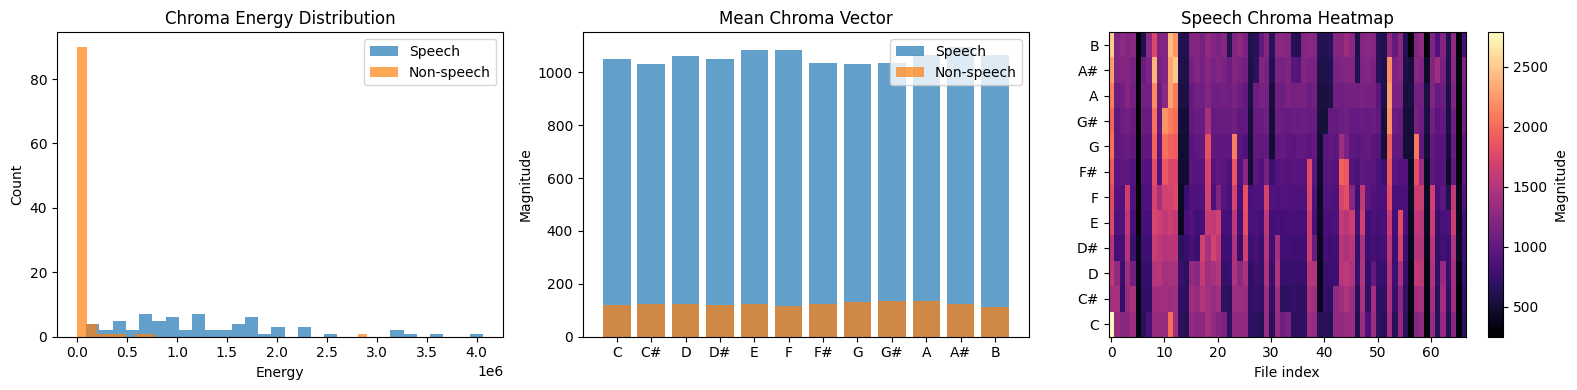


===== SUMMARY =====
Mean chroma energy (speech)     : 1293786.965363717
Mean chroma energy (non-speech) : 67533.00777665275


In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt

# =======================
# CONFIG
# =======================
speech_dir = r"D:\FPT_prj\preprocess_data\speech\chroma"
nonspeech_dir = r"D:\FPT_prj\preprocess_data\non-speech\chroma"

PITCH_LABELS = ['C', 'C#', 'D', 'D#', 'E', 'F',
                'F#', 'G', 'G#', 'A', 'A#', 'B']

# =======================
# LOAD + CLEAN CHROMA
# =======================
def load_chroma_folder(folder):
    chroma_vectors = []

    for file in os.listdir(folder):
        if not file.endswith(".npy"):
            continue

        path = os.path.join(folder, file)
        chroma = np.load(path)

        # Expect shape (12, T)
        if chroma.ndim != 2 or chroma.shape[0] != 12:
            print(f"Skip {file}: invalid shape {chroma.shape}")
            continue

        # Mean over time → (12,)
        chroma_mean = chroma.mean(axis=1)

        # Remove NaN / Inf / zero
        if not np.isfinite(chroma_mean).all():
            print(f"Skip {file}: contains NaN/Inf")
            continue
        if np.all(chroma_mean == 0):
            print(f"Skip {file}: all zeros")
            continue

        chroma_vectors.append(chroma_mean)

    if len(chroma_vectors) == 0:
        raise ValueError(f"No valid chroma files in {folder}")

    return np.array(chroma_vectors)


# =======================
# LOAD DATA
# =======================
speech_chroma = load_chroma_folder(speech_dir)
nonspeech_chroma = load_chroma_folder(nonspeech_dir)

print("Speech chroma shape     :", speech_chroma.shape)
print("Non-speech chroma shape :", nonspeech_chroma.shape)

# =======================
# FEATURE: CHROMA ENERGY
# =======================
speech_energy = np.mean(speech_chroma ** 2, axis=1)
nonspeech_energy = np.mean(nonspeech_chroma ** 2, axis=1)

# =======================
# VISUALIZATION
# =======================
plt.figure(figsize=(16, 4))

# --- (1) ENERGY DISTRIBUTION ---
plt.subplot(1, 3, 1)
plt.hist(speech_energy, bins=30, alpha=0.7, label="Speech")
plt.hist(nonspeech_energy, bins=30, alpha=0.7, label="Non-speech")
plt.title("Chroma Energy Distribution")
plt.xlabel("Energy")
plt.ylabel("Count")
plt.legend()

# --- (2) MEAN CHROMA VECTOR ---
plt.subplot(1, 3, 2)
plt.bar(PITCH_LABELS, speech_chroma.mean(axis=0),
        alpha=0.7, label="Speech")
plt.bar(PITCH_LABELS, nonspeech_chroma.mean(axis=0),
        alpha=0.7, label="Non-speech")
plt.title("Mean Chroma Vector")
plt.ylabel("Magnitude")
plt.legend()

# --- (3) CHROMA HEATMAP (SPEECH) ---
plt.subplot(1, 3, 3)
plt.imshow(speech_chroma.T,
           aspect='auto',
           origin='lower',
           cmap='magma')
plt.yticks(range(12), PITCH_LABELS)
plt.colorbar(label="Magnitude")
plt.title("Speech Chroma Heatmap")
plt.xlabel("File index")

plt.tight_layout()
plt.show()

# =======================
# NUMERICAL SUMMARY
# =======================
print("\n===== SUMMARY =====")
print("Mean chroma energy (speech)     :", speech_energy.mean())
print("Mean chroma energy (non-speech) :", nonspeech_energy.mean())



In [12]:
c = np.load(r"D:\FPT_prj\preprocess_data\speech\chroma\27_chroma.npy")
print("min:", c.min(), "max:", c.max(), "sum:", c.sum())


min: 1189.9177501407742 max: 3276.5499586686833 sum: 6097607.005302027


In [14]:
import numpy as np

def chroma_from_stft(stft_matrix, sr, n_fft):
    """
    stft_matrix: shape (freq_bins, time_frames)
    sr          : sample rate
    n_fft       : FFT size
    """
    num_bins, num_frames = stft_matrix.shape
    chroma = np.zeros((12, num_frames))

    for t in range(num_frames):
        for k in range(1, num_bins):
            magnitude = stft_matrix[k, t]
            f_k = k * sr / n_fft

            if f_k < 20:
                continue

            p = 12 * np.log2(f_k / 440.0)
            chroma_idx = int(np.round(p)) % 12
            chroma[chroma_idx, t] += magnitude

    return chroma


In [16]:
import os
import numpy as np

stft_dir   = r"D:\FPT_prj\preprocess_data\non-speech\stft"
chroma_dir = r"D:\FPT_prj\preprocess_data\non-speech\chroma"
os.makedirs(chroma_dir, exist_ok=True)

sr = 16000
n_fft = 512

for i in range(1,30):
    stft_path = os.path.join(stft_dir, f"{i}_stft.npy")

    if not os.path.exists(stft_path):
        print(f"Missing STFT: {i}_stft.npy")
        continue

    # load STFT magnitude
    stft = np.load(stft_path)

    # EXPECT (time, freq) → transpose
    if stft.shape[0] < stft.shape[1]:
        stft = stft.T   # (freq, time)

    # Ensure non-negative
    stft = np.abs(stft)

    chroma = chroma_from_stft(stft, sr, n_fft)

    save_path = os.path.join(chroma_dir, f"{i}_chroma.npy")
    np.save(save_path, chroma)

    print(f"{i}_stft.npy → chroma shape: {chroma.shape}, sum={chroma.sum():.4f}")


1_stft.npy → chroma shape: (12, 257), sum=260279.4168
2_stft.npy → chroma shape: (12, 257), sum=806902.0805
3_stft.npy → chroma shape: (12, 257), sum=1267622.6375
4_stft.npy → chroma shape: (12, 257), sum=285984.7288
5_stft.npy → chroma shape: (12, 248), sum=49887.2732
6_stft.npy → chroma shape: (12, 257), sum=369490.0060
7_stft.npy → chroma shape: (12, 257), sum=121111.5046
8_stft.npy → chroma shape: (12, 257), sum=75736.7097
9_stft.npy → chroma shape: (12, 257), sum=59171.3064
10_stft.npy → chroma shape: (12, 257), sum=87975.2126
11_stft.npy → chroma shape: (12, 257), sum=71616.4642
12_stft.npy → chroma shape: (12, 257), sum=314910.4652
13_stft.npy → chroma shape: (12, 257), sum=586333.6035
14_stft.npy → chroma shape: (12, 85), sum=17958.9350
15_stft.npy → chroma shape: (12, 241), sum=51426.1454
16_stft.npy → chroma shape: (12, 257), sum=1797655.1531
17_stft.npy → chroma shape: (12, 100), sum=20342.4496
18_stft.npy → chroma shape: (12, 257), sum=160865.6625
19_stft.npy → chroma shape